In [28]:
%pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from pathlib import Path
import matplotlib.pyplot as plt

# Tokens embedding

## First get the tokenizer from the first part

Nothing new here, just create a class for the tokenizer

In [30]:
import json
import regex

class Tokenizer:

    def __init__(self, tokenizer_path: str):
        with open(tokenizer_path) as f:
            tokenizer_data = json.load(f)
        split = next(filter(lambda t: t["type"] == "Split", tokenizer_data["pre_tokenizer"]["pretokenizers"]))
        self.split_regex = regex.compile(split["pattern"]["Regex"])

        # space is encoded as Ġ, for simplicity, just use space here.
        self.vocab = {k.replace("Ġ", " ").encode("utf-8"): v for k, v in tokenizer_data["model"]["vocab"].items()}
        added_tokens = {t["content"]: t["id"] for t in tokenizer_data["added_tokens"]}

        self.vocab.update(added_tokens)

        # inverse vocabulary for detokenization
        self.vocab_inv = { v: k for k, v in self.vocab.items() }

    def tokenize(self, text: str) -> list[int]:
        str_tokens = self.split_regex.findall(text)

        # Add specific markers for beginning and end of text
        str_tokens = ["<|begin_of_text|>"] + str_tokens + ["<|end_of_text|>"]

        tokens = []

        for str_token in str_tokens:
            parts = [bytes([b]) for b in str_token.encode("utf-8")]

            while True:
                # Iterate over all pairs and find the pair we want to merge the most
                min_idx = None
                min_rank = None
                for i, pair in enumerate(zip(parts[:-1], parts[1:])):
                    rank = self.vocab.get(pair[0] + pair[1])
                    if rank is not None and (min_rank is None or rank < min_rank):
                        min_idx = i
                        min_rank = rank

                # If there were no pairs we could merge, we're done!
                if min_rank is None:
                    break
                assert min_idx is not None

                # Otherwise, merge that pair and leave the rest unchanged. Then repeat.
                parts = parts[:min_idx] + [parts[min_idx] + parts[min_idx + 1]] + parts[min_idx + 2 :]

            tokens.extend(self.vocab[part] for part in parts)

        return tokens
    
    def detokenize(self, tokens: list[int]) -> str:
        decoded = b""
        for t in tokens:
            decoded += self.vocab_inv[t]

        return str(decoded)

In [31]:
model_dir = Path("models/Llama-3.2-1B")

tokenizer = Tokenizer(model_dir / "tokenizer.json")

In [32]:
tokenized_text = tokenizer.tokenize("This is a hello world")
print(tokenized_text)
detokenized_text = tokenizer.detokenize(tokenized_text)
print(detokenized_text)

[27, 91, 7413, 3659, 4424, 91, 29, 2028, 374, 264, 24748, 1917, 27, 91, 408, 3659, 4424, 91, 29]
b'<|begin_of_text|>This is a hello world<|end_of_text|>'


## Token embeddings

The tokenizer only translates a textual token to an arbitraty number. This number doesn't carry any meaning or concepts relative to the token.
This is the purpose of the embeddings. For Llama 3.2, a token embedding is a 2048 floats vector. This means that 2048 concepts or features can be stored for each token.

In [33]:
from pathlib import Path
import mmap
import numpy as np

def load_raw_model(path: str):
    model_dir = Path(path)
    model = {}
    with open(model_dir / "metadata.json") as file:
        metadata = json.load(file)
    for tensor_name, tensor_metadata in metadata.items():
        if tensor_name == "__metadata__":
            continue
        file = open(model_dir / f"{tensor_name}.raw", mode="rb")
        mmaped = mmap.mmap(file.fileno(), 0, prot=mmap.PROT_READ)
        model[tensor_name] = np.frombuffer(mmaped, dtype=np.float32).reshape(tensor_metadata["shape"])
    return model

First load the model tensors

In [ ]:
tensors = load_raw_model(model_dir / "tensors-fp32")

And fetch the embeddings tensor

In [35]:
embed_tokens = tensors["model.embed_tokens.weight"]

It is a 2D array. Its first dimension is the number of tokens in the vocabulary of the tokenizer. The second dimension is embedding size.

In [36]:
# embeddings must be the same size than the tokenizer's vocabulary size
assert embed_tokens.shape[0] == len(tokenizer.vocab)
display(embed_tokens.shape)

(128256, 2048)

By subscripting with a tokenized text (list of token numeric ids), we get an array containing the embeddings corresponding to each token.

In [37]:
embedded_text = embed_tokens[tokenized_text]
print(f"Tokens in the text: {len(tokenized_text)}")
print(f"Corresponding embeddings: {embedded_text.shape}")

Tokens in the text: 19
Corresponding embeddings: (19, 2048)


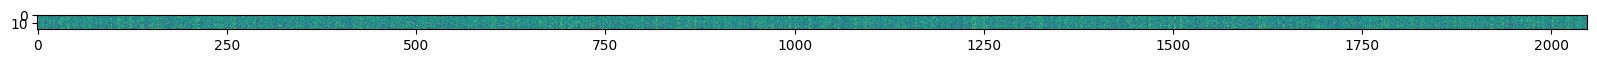

In [38]:
plt.figure(figsize = (20,1))
plt.imshow(embedded_text)